In [1]:
pip install timm torch torchvision numpy tqdm


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Pre Processing

In [1]:
import torch
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_phaseA = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


In [2]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

DATASET_DIR = "CAT_SKIN_SPLIT"

train_dataset = ImageFolder(f"{DATASET_DIR}/train", transform=transform_phaseA)
val_dataset   = ImageFolder(f"{DATASET_DIR}/val",   transform=transform_phaseA)
test_dataset  = ImageFolder(f"{DATASET_DIR}/test",  transform=transform_phaseA)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)


In [ ]:
print(train_dataset.class_to_idx)

{'Flea_Allergy': 0, 'Health': 1, 'Ringworm': 2, 'Scabies': 3}


ViT Extraction

In [4]:
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    "deit_small_patch16_224",
    pretrained=True,
    num_classes=0  # removes classifier head
)

model.to(device)
model.eval()

for param in model.parameters():
    param.requires_grad = False


c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import numpy as np
from tqdm import tqdm

def extract_features(dataloader, model):
    features = []
    labels = []

    with torch.no_grad():
        for imgs, lbls in tqdm(dataloader):
            imgs = imgs.to(device)

            embeddings = model(imgs)  # [B, 384]
            features.append(embeddings.cpu().numpy())
            labels.append(lbls.numpy())

    return np.vstack(features), np.hstack(labels)


In [6]:
X_train, y_train = extract_features(train_loader, model)
X_val,   y_val   = extract_features(val_loader, model)
X_test,  y_test  = extract_features(test_loader, model)


100%|██████████| 5/5 [00:26<00:00,  5.33s/it]


In [ ]:
# Save DeiT feature extractor
import torch
torch.save(model.state_dict(), "models/deit_feature_extractor.pth")
print("DeiT model saved.")

DeiT model saved.


In [8]:
np.save("X_train_phaseA.npy", X_train)
np.save("y_train_phaseA.npy", y_train)

np.save("X_val_phaseA.npy", X_val)
np.save("y_val_phaseA.npy", y_val)

np.save("X_test_phaseA.npy", X_test)
np.save("y_test_phaseA.npy", y_test)


In [9]:
import numpy as np

X_train = np.load("X_train_phaseA.npy")
y_train = np.load("y_train_phaseA.npy")

X_val   = np.load("X_val_phaseA.npy")
y_val   = np.load("y_val_phaseA.npy")

X_test  = np.load("X_test_phaseA.npy")
y_test  = np.load("y_test_phaseA.npy")

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (679, 384) (679,)
Val  : (146, 384) (146,)
Test : (148, 384) (148,)


In [ ]:
print("NaNs in X_train:", np.isnan(X_train).sum()) #Nan Values in X_train
print("Infs in X_train:", np.isinf(X_train).sum()) #Infinite Values in X_train

NaNs in X_train: 0
Infs in X_train: 0


In [11]:
feature_variance = np.var(X_train, axis=0)

print("Min variance:", feature_variance.min())
print("Mean variance:", feature_variance.mean())
print("Max variance:", feature_variance.max())


Min variance: 0.13237718
Mean variance: 1.1105404
Max variance: 2.3447716


In [12]:
import numpy as np

classes = np.unique(y_train)

centroids = {}
for cls in classes:
    centroids[cls] = X_train[y_train == cls].mean(axis=0)

# Compute pairwise centroid distances
for i in classes:
    for j in classes:
        if i < j:
            dist = np.linalg.norm(centroids[i] - centroids[j])
            print(f"Distance between class {i} and {j}: {dist:.2f}")


Distance between class 0 and 1: 12.69
Distance between class 0 and 2: 8.21
Distance between class 0 and 3: 10.32
Distance between class 1 and 2: 7.82
Distance between class 1 and 3: 9.00
Distance between class 2 and 3: 7.21


Flea Allergy vs Health: 12.69 — most separable pair
Ringworm vs Scabies: 7.21 — closest pair, explaining why these two are harder to distinguish

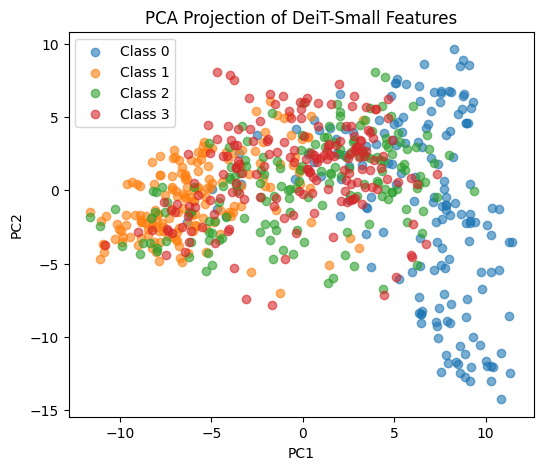

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train)

plt.figure(figsize=(6, 5))
for cls in np.unique(y_train):
    plt.scatter(
        X_2d[y_train == cls, 0],
        X_2d[y_train == cls, 1],
        label=f"Class {cls}",
        alpha=0.6
    )

plt.legend()
plt.title("PCA Projection of DeiT-Small Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

train_acc = accuracy_score(y_train, clf.predict(X_train))
val_acc   = accuracy_score(y_val,   clf.predict(X_val))

print("Train accuracy:", train_acc)
print("Val accuracy  :", val_acc)


Train accuracy: 1.0
Val accuracy  : 0.9452054794520548
